In [1]:
import pandas as pd

df = pd.read_excel("../data/ethiopia.xls")
df.head()

ModuleNotFoundError: No module named 'pandas'

In [2]:
import os
print(os.listdir("../data"))

[]


In [3]:
df = pd.read_excel("ethiopia.xls")


NameError: name 'pd' is not defined

In [2]:
import pandas as pd

In [3]:
import os
print(os.listdir("../data"))

['ethiopia.csv', 'ethiopia_clean.csv']


In [4]:
import pandas as pd

df = pd.read_excel("../data/ethiopia.xls")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/ethiopia.xls'

In [5]:
import os
print(os.listdir("../data"))

['ethiopia.csv', 'ethiopia_clean.csv']


In [6]:
import pandas as pd

df = pd.read_csv("../data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [7]:
df.columns

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M'],
      dtype='object')

In [8]:
df["Country"] = "Ethiopia"

df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df["Month"] = df["DATE"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [9]:
import numpy as np

df.replace(-999, np.nan, inplace=True)

In [10]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


In [11]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [12]:
missing = df.isna().sum()
percent = (missing / len(df)) * 100

pd.DataFrame({"Missing": missing, "Percent": percent})

,Missing,Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [13]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3)

print("Outliers count:", outliers.sum())

Outliers count: 137


In [14]:
df = df[df.isna().mean(axis=1) < 0.3]

In [15]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

<Axes: title={'center': 'Monthly Avg Temperature'}, xlabel='Month'>

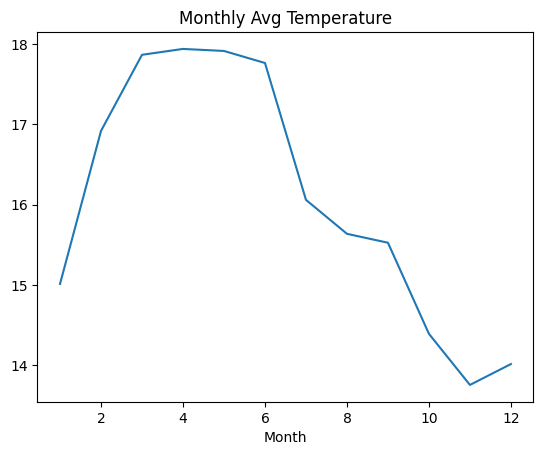

In [16]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(title="Monthly Avg Temperature")

## Time Series Analysis: Temperature

The monthly average temperature shows a clear seasonal pattern.

Temperatures increase from January and peak around March to May, corresponding to the dry season. Afterward, temperatures decline during the rainy months due to increased cloud cover and reduced solar radiation.

The coolest months occur towards the end of the year, particularly around October and November.

<Axes: title={'center': 'Monthly Rainfall'}, xlabel='Month'>

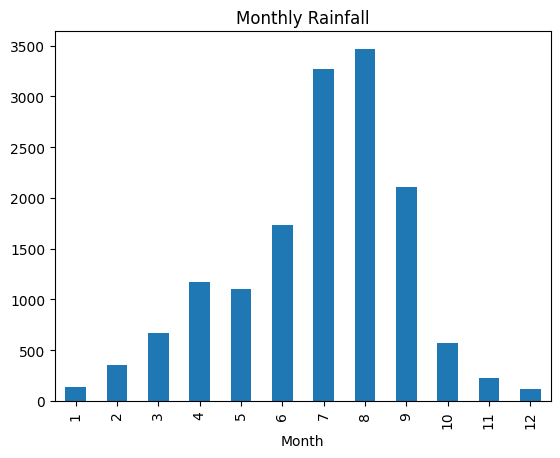

In [17]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", title="Monthly Rainfall")

## Time Series Analysis: Rainfall

Rainfall exhibits strong seasonal variation.

Precipitation is minimal during the dry season (November to February) and increases steadily from March onward.

The peak rainy season occurs between June and September, with the highest rainfall observed in July and August. This pattern reflects Ethiopia's monsoonal climate system.

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [19]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

NameError: name 'sns' is not defined

NameError: name 'plt' is not defined

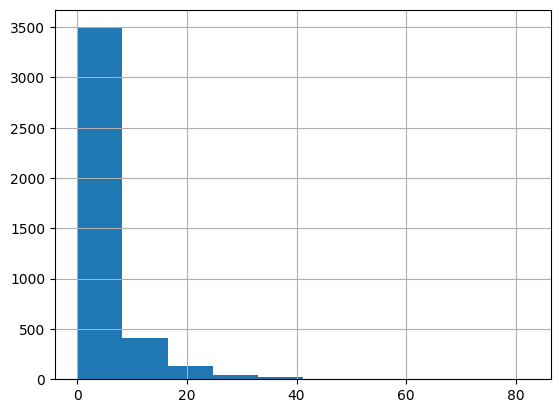

In [20]:
df["PRECTOTCORR"].hist()
plt.title("Rainfall Distribution")

In [21]:
git add notebooks/
git commit -m "feat: Ethiopia EDA analysis"
git push

SyntaxError: invalid syntax (3034477490.py, line 1)

missing = df.isna().sum()
percent = (missing / len(df)) * 100

pd.DataFrame({"Missing": missing, "Percent": percent})

In [22]:
missing = df.isna().sum()
percent = (missing / len(df)) * 100

pd.DataFrame({"Missing": missing, "Percent": percent})

,Missing,Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


## Handling Missing Values

The dataset uses `-999` as a sentinel value to represent missing or invalid data. These values were replaced with `NaN` to ensure accurate statistical analysis.

This step is critical because leaving `-999` would distort summary statistics and visualizations.

In [8]:
from scipy.stats import zscore
import numpy as np

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
print((z_scores > 3).sum())

137


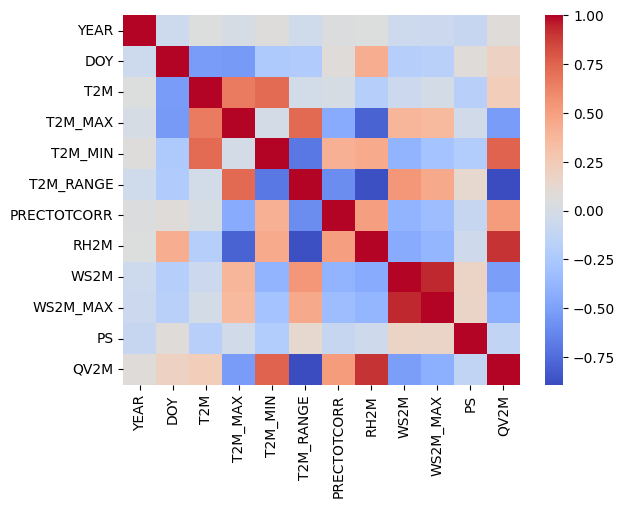

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

## Correlation Analysis

A correlation heatmap was used to examine relationships between numerical variables.

Strong correlations were observed between:
- Temperature-related variables (T2M, T2M_MAX, T2M_MIN)
- Wind speed variables (WS2M and WS2M_MAX)

These relationships indicate consistent physical dependencies within the climate system.

Further analysis of scatter plots helps validate these correlations.

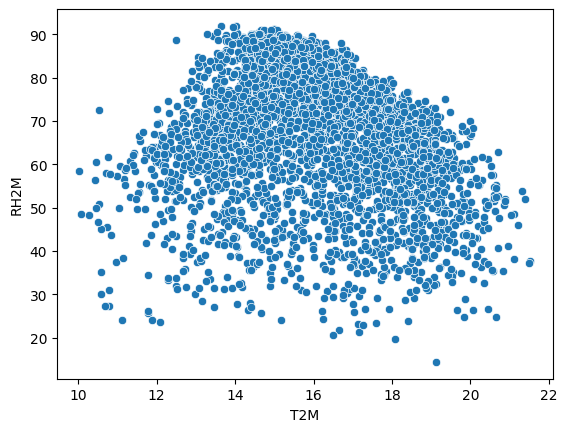

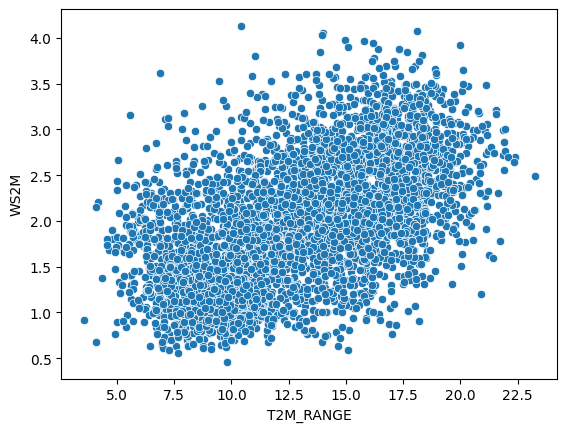

In [10]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

## Scatter Plot Analysis

Scatter plots were used to explore relationships between key variables.

- Temperature vs Humidity: Shows a moderate relationship, suggesting that higher temperatures may influence moisture levels.
- Temperature Range vs Wind Speed: Indicates how atmospheric dynamics affect temperature variability.

These visualizations help uncover underlying patterns not visible in aggregate statistics.

<Axes: >

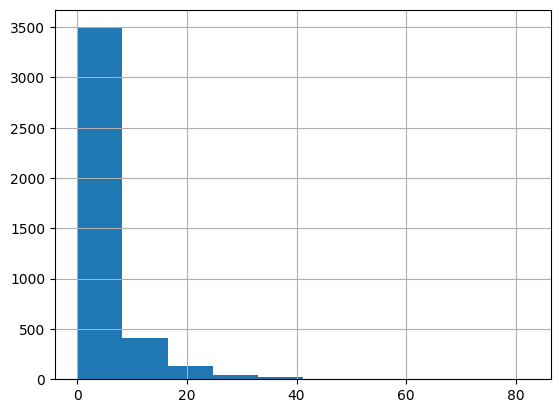

In [11]:
df["PRECTOTCORR"].hist()

In [13]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("../data/kenya.csv")
df.replace(-999, np.nan, inplace=True)
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df.to_csv("../data/kenya_clean.csv", index=False)

In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/nigeria.csv")

df["Country"] = "Nigeria"

df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df.replace(-999, np.nan, inplace=True)

df = df.drop_duplicates()

df.fillna(method="ffill", inplace=True)

df.to_csv("../data/nigeria_clean.csv", index=False)

print("Nigeria cleaned ✅")

Nigeria cleaned ✅


C:\Users\TigestH\AppData\Local\Temp\ipykernel_8516\392233551.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/tanzania.csv")

df["Country"] = "Tanzania"

df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df.replace(-999, np.nan, inplace=True)

df = df.drop_duplicates()

df.fillna(method="ffill", inplace=True)

df.to_csv("../data/tanzania_clean.csv", index=False)

print("Tanzania cleaned ✅")

Tanzania cleaned ✅


C:\Users\TigestH\AppData\Local\Temp\ipykernel_8516\2914306701.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/tanzania.csv")

df["Country"] = "Tanzania"

df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df.replace(-999, np.nan, inplace=True)

df = df.drop_duplicates()

df.fillna(method="ffill", inplace=True)

df.to_csv("../data/tanzania_clean.csv", index=False)

print("Tanzania cleaned ✅")

Tanzania cleaned ✅


C:\Users\TigestH\AppData\Local\Temp\ipykernel_8516\2914306701.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/sudan.csv")

df["Country"] = "Sudan"

df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df.replace(-999, np.nan, inplace=True)

df = df.drop_duplicates()

df.fillna(method="ffill", inplace=True)

df.to_csv("../data/sudan_clean.csv", index=False)

print("Sudan cleaned ✅")

Sudan cleaned ✅


C:\Users\TigestH\AppData\Local\Temp\ipykernel_8516\762643757.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)
